Nama : Muhammad Hidayat

Nim  :241061007

Tugas UTS

Pemodelan Simulasi dan Optimasi

In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('data soal UTS.xlsx')
df.columns = ['Y', 'X1', 'X2', 'X3', 'X4']
df.head()

,Y,X1,X2,X3,X4
0,71.28,0,12.53,56.90,71.11
1,73.80,1,13.62,71.40,69.55
2,70.25,0,13.00,71.43,67.85
3,73.64,0,13.43,74.53,68.84
4,75.11,1,13.87,79.24,71.34




Output yang terlihat: Tabel dengan 5 baris data, masing-masing kolom Y, X1, X2, X3, X4 sudah terisi.



In [20]:
# df = pd.read_excel('data soal UTS.xlsx')
# df.columns = ['Y', 'X1', 'X2', 'X3', 'X4']

X = df[['X1', 'X2', 'X3', 'X4']]
X = sm.add_constant(X)
model = sm.OLS(df['Y'], X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     36.07
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           9.24e-05
Time:                        02:04:12   Log-Likelihood:                -16.957
No. Observations:                  12   AIC:                             43.91
Df Residuals:                       7   BIC:                             46.34
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.9539     30.443      0.918      0.3

-R-squared = 0.954 → model menjelaskan 95.4% variasi Y.

Adj. R-squared = 0.927 → sudah disesuaikan dengan jumlah prediktor.

Koefisien:

X2 (p=0.001) signifikan secara statistik (α=0.05).

X1, X3, X4 tidak signifikan (p > 0.05).

Kondisi (Condition Number) besar (8.2e+03) → indikasi adanya multikolinearitas.

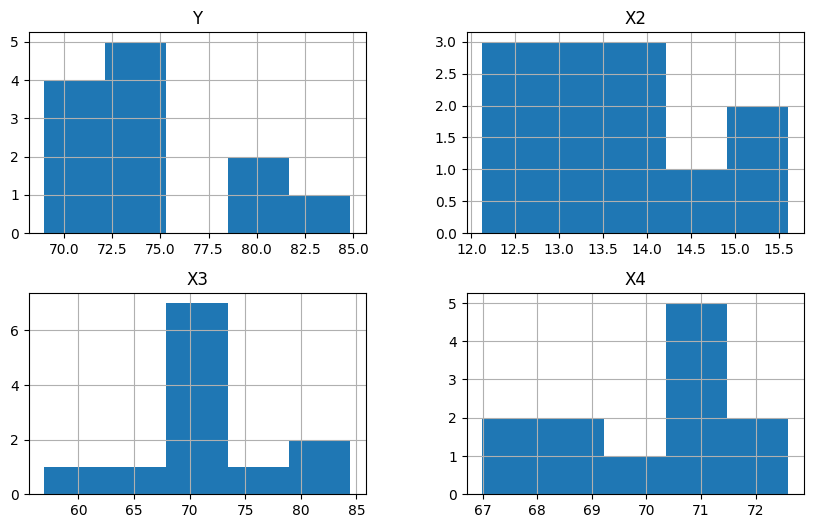

X1
0    0.5
1    0.5
Name: proportion, dtype: float64
Y: p=0.1016
X2: p=0.7685
X3: p=0.2186
X4: p=0.3917


In [22]:
df[['Y','X2','X3','X4']].hist(bins=5, figsize=(10,6))
plt.show()

print(df['X1'].value_counts(normalize=True))

for v in ['Y','X2','X3','X4']:
    s, p = shapiro(df[v])
    print(f'{v}: p={p:.4f}')

-Hasil: semua p-value > 0.05 (Y:0.1016, X2:0.7685, X3:0.2186, X4:0.3917) → gagal tolak H0, artinya data cukup normal.

In [23]:
print("Y : mean =", df['Y'].mean(), "std =", df['Y'].std())
print("X1: p =", df['X1'].mean())
print("X2: mean =", df['X2'].mean(), "std =", df['X2'].std())
print("X3: mean =", df['X3'].mean(), "std =", df['X3'].std())
print("X4: mean =", df['X4'].mean(), "std =", df['X4'].std())

Y : mean = 74.69833333333334 std = 4.827270701363495
X1: p = 0.5
X2: mean = 13.636666666666665 std = 1.0396532055828942
X3: mean = 71.33999999999999 std = 6.7217381410140975
X4: mean = 70.19833333333334 std = 1.71518794800153


-Menampilkan nilai rata-rata (mean) dan standar deviasi (std) untuk setiap variabel.

Untuk X1 (variabel biner), mean = 0.5 → proporsi kelas 1 adalah 50%.

Nilai-nilai ini akan digunakan nanti untuk simulasi data.



In [25]:
np.random.seed(42)
n = 500

df_sim = pd.DataFrame({
    'X1': np.random.binomial(1, df['X1'].mean(), n),
    'X2': np.random.normal(df['X2'].mean(), df['X2'].std(), n),
    'X3': np.random.normal(df['X3'].mean(), df['X3'].std(), n),
    'X4': np.random.normal(df['X4'].mean(), df['X4'].std(), n)
})

df_sim['Y'] = (model.params['const'] +
               model.params['X1']*df_sim['X1'] +
               model.params['X2']*df_sim['X2'] +
               model.params['X3']*df_sim['X3'] +
               model.params['X4']*df_sim['X4'] +
               np.random.normal(0, model.resid.std(), n))

print(df_sim.head())

   X1         X2         X3         X4          Y
0   0  13.991974  75.265012  72.431064  74.322596
1   1  15.587234  68.924933  72.876619  84.961298
2   1  14.624778  75.310227  70.253226  78.885026
3   1  13.036887  78.792415  68.906080  71.369150
4   0  12.702627  76.855066  70.987272  69.457993


-Seed: np.random.seed(42) agar hasil simulasi dapat direproduksi.

Ukuran sampel simulasi: n = 500.

Membangkitkan variabel independen:

X1 dari distribusi binomial (sesuai proporsi data asli).

X2, X3, X4 dari distribusi normal (mean dan std dari data asli).

Membangkitkan Y:

Menggunakan koefisien model asli (model.params).

Ditambah error acak dari distribusi normal dengan standar deviasi = residual standar dari model asli.

Menampilkan 5 baris pertama data simulasi.

In [27]:
X_sim = sm.add_constant(df_sim[['X1','X2','X3','X4']])
model_sim = sm.OLS(df_sim['Y'], X_sim).fit()
print(model_sim.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     3348.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:14:10   Log-Likelihood:                -714.43
No. Observations:                 500   AIC:                             1439.
Df Residuals:                     495   BIC:                             1460.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.8711      2.074     14.402      0.0

Proses sama seperti cell 2, tetapi menggunakan data simulasi.

Tujuan: Membandingkan apakah model hasil simulasi dapat mereproduksi koefisien asli.

Output:

R-squared = 0.964 → sangat tinggi.

Semua koefisien signifikan (p=0.000) karena ukuran sampel besar (500) sehingga power uji tinggi.

Koefisien estimasi (X1=0.929, X2=4.915, X3=-0.136, X4=-0.184) cukup dekat dengan koefisien asli (0.812, 4.868, -0.133, -0.150).



In [28]:
print("Koefisien asli:")
print(model.params.round(4))
print("\nKoefisien simulasi:")
print(model_sim.params.round(4))
print(f"\nR-squared asli: {model.rsquared:.4f}")
print(f"R-squared simulasi: {model_sim.rsquared:.4f}")

Koefisien asli:
const    27.9539
X1        0.8124
X2        4.8684
X3       -0.1334
X4       -0.1500
dtype: float64

Koefisien simulasi:
const    29.8711
X1        0.9292
X2        4.9150
X3       -0.1364
X4       -0.1841
dtype: float64

R-squared asli: 0.9537
R-squared simulasi: 0.9644


Mencetak koefisien model asli dan model simulasi (dibulatkan 4 desimal).

Membandingkan R-squared.

Kesimpulan: Koefisien simulasi sangat mendekati koefisien asli, R-squared juga mirip. Ini menandakan model regresi yang diestimasi dari data asli cukup stabil dan mampu menghasilkan data sintetis yang konsisten.